# Trabajo Práctico 1: Búsqueda y Optimización

## Búsqueda Global

Un almacén tiene distribuidos 48 productos en 6 estanterías de 8 productos cada uno en una distribución como la que se puede observar en la imagen. Además, el almacén cuenta con una zona de carga señalizada como "C" en el diagrama:


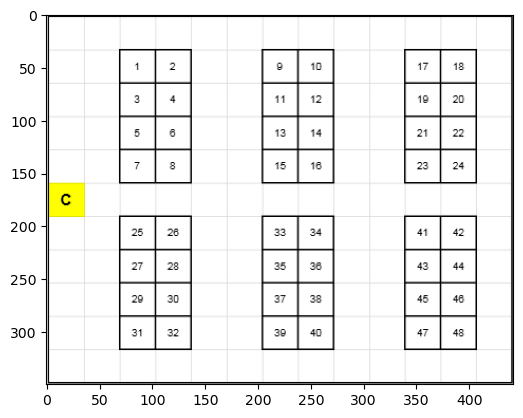

In [2]:
from skimage import io
import matplotlib.pyplot as plt

image = io.imread("https://drive.google.com/uc?export=view&id=1uXv0hJ7gNnpY_uErkTR-bcAlmq6VtbRV")
plt.imshow(image)
plt.show()

Programe el agente que usará el montacargas para navegar en el almacén usando un algoritmo A*. Tenga en cuenta las siguientes indicaciones:

* El agente solo puede moverse en los pasillos no ocupados por estantes

* El agente debe recibir como consigna la estantería a la que se desea mover el montacargas. Como la casilla numerada que reciba como consigna no es accesible, el agente debe detenerse en la casilla **horizontalmente adyacente** a la que tenga acceso

* El agente puede o no recibir una consigna de casilla inicial desde comenzar a navegar. En caso de que no se proporcione el dato, asuma que el movimiento se inicia en la estación de carga

* El costo de movimiento es uniforme. La heurística utilizada debe determinarla usted

In [ ]:
import heapq 
import matplotlib.pyplot as plt
import numpy as np
import time
from IPython.display import display, clear_output
import matplotlib.animation as animation

#Guarda poscion anterior, actual y caracteristicas iniciales
class Nodo: 
    def __init__(self, posicion, padre=None):
        self.posicion = posicion  
        self.padre = padre        
        self.g = 0                
        self.h = 0                
        self.f = 0                

    def __lt__(self, otro):
        if self.f == otro.f:
            return self.h < otro.h
        return self.f < otro.f

    def __eq__(self, otro):
        return self.posicion == otro.posicion

#Carga la matriz del almacen, busca la posicion del producto, calcula distancias y halla la ruta mas optima
class AgenteAlmacen:
    def __init__(self, mapa_almacen):
        self.mapa = mapa_almacen 
        self.filas = len(mapa_almacen)
        self.columnas = len(mapa_almacen[0])
        self.estacion_carga = self._encontrar_casilla('C')

    def _encontrar_casilla(self, valor):
        for i in range(self.filas):
            for j in range(self.columnas):
                if self.mapa[i][j] == valor:
                    return (i, j)
        return None
    
    def _obtener_metas_adyacentes(self, posicion_estante):
        fila, col = posicion_estante
        metas_validas = []
        movimientos_horizontales = [(0, -1), (0, 1)]
        
        for df, dc in movimientos_horizontales:
            n_fila, n_col = fila + df, col + dc
            if (0 <= n_fila < self.filas and 0 <= n_col < self.columnas):
                if self.mapa[n_fila][n_col] == 0 or self.mapa[n_fila][n_col] == 'C':
                    metas_validas.append((n_fila, n_col))
                    
        return metas_validas
    
    def heuristica_manhattan(self, pos_actual, metas_posibles):
        distancias = []
        for meta in metas_posibles:
            dist = abs(pos_actual[0] - meta[0]) + abs(pos_actual[1] - meta[1])
            distancias.append(dist)
        return min(distancias)
    
    def buscar_ruta(self, id_estanteria, inicio=None):
        
        if id_estanteria == 0:
            raise ValueError("Error: '0' es un pasillo, no un producto válido.")
        if id_estanteria == 'C':
            raise ValueError("Error: 'C' es la estación de carga, no un producto.")
        
        # 1. Validación de Entrada
        if inicio is None:
            inicio = self.estacion_carga
        else:
            if not (0 <= inicio[0] < self.filas and 0 <= inicio[1] < self.columnas):
                raise IndexError(f"Error: Coordenada de inicio {inicio} esta fuera del almacen.")
            valor_casilla = self.mapa[inicio[0]][inicio[1]]
            if valor_casilla != 0 and valor_casilla != 'C':
                raise ValueError(f"Error: Coordenada de incio {inicio} es una estanteria ('{valor_casilla}').")

        pos_estante = self._encontrar_casilla(id_estanteria)
        if pos_estante is None:
            raise ValueError("Error: Producto no encontrado, cambie el valor a uno entre 1 y 48.")

        metas = self._obtener_metas_adyacentes(pos_estante)
        if not metas:
            raise ValueError("Error: No hay metas adyacentes.")

        # 2. Inicialización de estructuras
        nodo_inicio = Nodo(inicio)
        lista_abierta = []
        heapq.heappush(lista_abierta, nodo_inicio)
        
        lista_cerrada = set()
        orden_exploracion = []

        movimientos = [(-1, 0), (1, 0), (0, -1), (0, 1)]

        while len(lista_abierta) > 0:
            nodo_actual = heapq.heappop(lista_abierta)

            # Chequea la meta
            if nodo_actual.posicion in metas:
                ruta = []
                actual = nodo_actual
                while actual is not None:
                    ruta.append(actual.posicion)
                    actual = actual.padre
                # Retornamos la ruta final y el orden exacto de exploracion
                return ruta[::-1], orden_exploracion 

            # Añadimos a los visitados
            if nodo_actual.posicion not in lista_cerrada:
                lista_cerrada.add(nodo_actual.posicion)
                orden_exploracion.append(nodo_actual.posicion)

            # Expansión de sucesores
            for mov in movimientos:
                n_fila = nodo_actual.posicion[0] + mov[0]
                n_col = nodo_actual.posicion[1] + mov[1]
                pos_sucesora = (n_fila, n_col)

                if (0 <= n_fila < self.filas and 0 <= n_col < self.columnas):
                    if self.mapa[n_fila][n_col] == 0 or self.mapa[n_fila][n_col] == 'C':
                        if pos_sucesora in lista_cerrada:
                            continue

                        sucesor = Nodo(pos_sucesora, nodo_actual)
                        sucesor.g = nodo_actual.g + 1
                        sucesor.h = self.heuristica_manhattan(sucesor.posicion, metas)
                        sucesor.f = sucesor.g + sucesor.h

                        en_abierta_con_menor_costo = False
                        for nodo_abierto in lista_abierta:
                            if sucesor == nodo_abierto and sucesor.g >= nodo_abierto.g:
                                en_abierta_con_menor_costo = True
                                break
                        
                        if not en_abierta_con_menor_costo:
                            heapq.heappush(lista_abierta, sucesor)

        return None, orden_exploracion

#Genera gifs de los casos que no devuelven error
def generar_gif_caso(mapa_almacen, ruta, orden_exploracion, id_objetivo, metas, inicio, nombre_archivo):
    filas = len(mapa_almacen)
    columnas = len(mapa_almacen[0])
    
    color_pasillo = [1.0, 1.0, 1.0]
    color_estante = [0.8, 0.8, 0.8]
    color_inicio = [0.2, 0.8, 0.2]
    color_meta = [0.9, 0.3, 0.3]
    color_objetivo = [0.2, 0.5, 0.9]
    color_explorado = [0.5, 0.9, 0.9]
    color_ruta = [1.0, 0.9, 0.4]

    fig, ax = plt.subplots(figsize=(10, 5))
    
    # 1. Pre-calcular todos los estados (fotogramas) de la animación
    fotogramas_data = []
    
    # Fase 1: Exploración (Aceleramos un poco la visualización para que el GIF no sea infinito)
    paso_exp = max(1, len(orden_exploracion) // 15) # Muestra la exploración en 15 saltos
    for i in range(0, len(orden_exploracion), paso_exp):
        fotogramas_data.append({
            'titulo': f"Fase 1: A* Analizando... | Nodos: {i+1}",
            'explorados': orden_exploracion[:i+1],
            'ruta': [], 'pos': None
        })
    # Aseguramos guardar el estado final de la exploración
    fotogramas_data.append({
        'titulo': f"Fase 1: Analisis Completo | Nodos: {len(orden_exploracion)}",
        'explorados': orden_exploracion,
        'ruta': [], 'pos': None
    })

    # Fase 2: Ejecución de la Ruta
    if ruta:
        # Añadimos unos frames de pausa antes de arrancar
        for _ in range(3): 
            fotogramas_data.append(fotogramas_data[-1].copy())
            
        for i, nodo in enumerate(ruta):
            fotogramas_data.append({
                'titulo': f"Fase 2: Ejecutando Ruta | Paso: {i}/{len(ruta)-1}",
                'explorados': orden_exploracion,
                'ruta': ruta[:i+1], 'pos': nodo
            })
            
        # Añadimos frames al final para que el GIF se detenga un momento antes de repetirse
        for _ in range(5):
            fotogramas_data.append(fotogramas_data[-1].copy())

    # 2. Función que Matplotlib llamará para dibujar cada fotograma
    def actualizar(frame_data):
        ax.clear()
        imagen = np.ones((filas, columnas, 3))
        
        # Desempaquetar datos del frame actual
        explorados = frame_data['explorados']
        ruta_vis = frame_data['ruta']
        pos_montacargas = frame_data['pos']
        titulo = frame_data['titulo']
        
        # --- Lógica de dibujo  ---
        for i in range(filas):
            for j in range(columnas):
                celda = mapa_almacen[i][j]
                if celda == 0 or celda == 'C':
                    imagen[i, j] = color_pasillo
                    if celda == 'C':
                        ax.text(j, i, 'C', ha='center', va='center', alpha=0.3)
                else: 
                    if celda == id_objetivo:
                        imagen[i, j] = color_objetivo
                        ax.text(j, i, str(celda), ha='center', va='center', color='white', fontweight='bold')
                    else:
                        imagen[i, j] = color_estante
                        ax.text(j, i, str(celda), ha='center', va='center', fontsize=8)

        for exp in explorados:
            if mapa_almacen[exp[0]][exp[1]] not in ['C'] and exp not in metas and exp != inicio:
                imagen[exp[0], exp[1]] = color_explorado
                ax.text(exp[1], exp[0], 'x', ha='center', va='center', color='gray', alpha=0.5, fontsize=6)

        for paso in ruta_vis:
            if paso != inicio and paso not in metas:
                imagen[paso[0], paso[1]] = color_ruta

        if len(ruta_vis) > 1:
            y_ruta = [p[0] for p in ruta_vis]
            x_ruta = [p[1] for p in ruta_vis]
            ax.plot(x_ruta, y_ruta, color='black', linewidth=2, linestyle='--')

        for m in metas:
            imagen[m[0], m[1]] = color_meta
            ax.text(m[1], m[0], 'Meta', ha='center', va='center', color='white', fontsize=7, fontweight='bold')
            
        imagen[inicio[0], inicio[1]] = color_inicio
        ax.text(inicio[1], inicio[0], 'Inicio', ha='center', va='center', color='white', fontsize=7, fontweight='bold')

        if pos_montacargas:
            ax.text(pos_montacargas[1], pos_montacargas[0], '[]', ha='center', va='center', fontsize=16)

        ax.imshow(imagen)
        ax.set_xticks(np.arange(-0.5, columnas, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, filas, 1), minor=True)
        ax.grid(which="minor", color="black", linestyle='-', linewidth=1)
        ax.tick_params(which="minor", size=0)
        ax.set_title(titulo, fontsize=14)

    # 3. Crear y guardar la animación
    print(f"Generando {nombre_archivo}...")
    ani = animation.FuncAnimation(fig, actualizar, frames=fotogramas_data, repeat=True)
    ani.save(nombre_archivo, writer='pillow', fps=4) # 4 frames por segundo
    plt.close(fig)
    print(f"¡Listo! {nombre_archivo} guardado.")


def generar_imagen_error(mapa_almacen, inicio, objetivo, mensaje_error, nombre_archivo):
    filas = len(mapa_almacen)
    columnas = len(mapa_almacen[0])

    fig, ax = plt.subplots(figsize=(10, 6))
    imagen = np.ones((filas, columnas, 3))

    # Paleta de colores para errores
    color_pasillo = [1.0, 1.0, 1.0]
    color_estante = [0.8, 0.8, 0.8]
    color_error = [1.0, 0.4, 0.4]

    # 1. Dibujar el mapa estático
    for i in range(filas):
        for j in range(columnas):
            celda = mapa_almacen[i][j]
            if celda == 0 or celda == 'C':
                imagen[i, j] = color_pasillo
                if celda == 'C':
                    ax.text(j, i, 'C', ha='center', va='center', alpha=0.3)
            else:
                imagen[i, j] = color_estante
                ax.text(j, i, str(celda), ha='center', va='center', fontsize=8)

    # 2. Lógica Visual para Errores de INICIO (Casos 3 y 4)
    if inicio is not None:
        # Caso 4: Si el inicio está completamente fuera del mapa
        if not (0 <= inicio[0] < filas and 0 <= inicio[1] < columnas):
            ax.plot(inicio[1], inicio[0], marker='X', color='red', markersize=15)
            ax.text(inicio[1], inicio[0] - 0.7, 'INICIO\nFUERA DE RANGO', color='red', ha='center', fontweight='bold')
            ax.set_xlim(min(-1, inicio[1]-2), max(columnas, inicio[1]+2))
            ax.set_ylim(max(filas, inicio[0]+2), min(-1, inicio[0]-2))
        else:
            # Caso 3: Si el inicio está dentro, pero choca con una estantería
            if mapa_almacen[inicio[0]][inicio[1]] != 0 and mapa_almacen[inicio[0]][inicio[1]] != 'C':
                imagen[inicio[0], inicio[1]] = color_error
                ax.text(inicio[1], inicio[0], 'INICIO\nINVALIDO', ha='center', va='center', color='black', fontsize=7, fontweight='bold')
            else:
                # CORRECCIÓN: Inicio válido (Pintamos la celda entera de verde con texto blanco)
                color_inicio = [0.2, 0.8, 0.2] # Verde
                imagen[inicio[0], inicio[1]] = color_inicio
                ax.text(inicio[1], inicio[0], 'Inicio', ha='center', va='center', color='white', fontsize=7, fontweight='bold')

    # 3. Lógica Visual para Errores de OBJETIVO (Casos 5, 6 y 7)
    pos_obj = None
    for i in range(filas):
        for j in range(columnas):
            if mapa_almacen[i][j] == objetivo:
                pos_obj = (i, j)

    if pos_obj:
        # CORRECCIÓN: Verificamos si el objetivo es realmente inválido (0 o 'C')
        if objetivo == 0 or objetivo == 'C':
            imagen[pos_obj[0], pos_obj[1]] = color_error
            ax.text(pos_obj[1], pos_obj[0], 'OBJETIVO\nINVALIDO', ha='center', va='center', color='black', fontsize=7, fontweight='bold')
        else:
            # Si el objetivo es válido (ej. 29), lo pintamos de azul para indicar que está correcto
            color_objetivo = [0.2, 0.5, 0.9] # Azul
            imagen[pos_obj[0], pos_obj[1]] = color_objetivo
            ax.text(pos_obj[1], pos_obj[0], str(objetivo), ha='center', va='center', color='white', fontweight='bold')
    elif isinstance(objetivo, int) and (objetivo < 1 or objetivo > 48):
        # Caso 7: El producto no existe en ninguna parte (ej. 49)
        ax.text(columnas/2, filas/2, f"EL PRODUCTO {objetivo}\nNO EXISTE EN INVENTARIO", ha='center', va='center', color='red', fontsize=18, fontweight='bold', alpha=0.6)

    # 4. Detalles gráficos y renderizado
    ax.imshow(imagen)
    ax.set_xticks(np.arange(-0.5, columnas, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, filas, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle='-', linewidth=1)
    ax.tick_params(which="minor", size=0)

    # Ponemos el texto de la excepción de Python como título del gráfico
    ax.set_title(f"REPORTE DE ERROR: {mensaje_error}", fontsize=11, color='darkred', fontweight='bold', pad=15)

    plt.tight_layout()
    plt.savefig(nombre_archivo, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Imagen de error guardada: {nombre_archivo}")


matriz_almacen = [
    [ 0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0 ],
    [ 0,   0,   1,   2,   0,   0,   9,  10,   0,   0,  17,  18,   0 ],
    [ 0,   0,   3,   4,   0,   0,  11,  12,   0,   0,  19,  20,   0 ],
    [ 0,   0,   5,   6,   0,   0,  13,  14,   0,   0,  21,  22,   0 ],
    [ 0,   0,   7,   8,   0,   0,  15,  16,   0,   0,  23,  24,   0 ],
    [ 'C', 0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0 ],
    [ 0,   0,  25,  26,   0,   0,  33,  34,   0,   0,  41,  42,   0 ],
    [ 0,   0,  27,  28,   0,   0,  35,  36,   0,   0,  43,  44,   0 ],
    [ 0,   0,  29,  30,   0,   0,  37,  38,   0,   0,  45,  46,   0 ],
    [ 0,   0,  31,  32,   0,   0,  39,  40,   0,   0,  47,  48,   0 ],
    [ 0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0 ]
]

agente = AgenteAlmacen(matriz_almacen)

# Definimos los casos de pruebas
casos_presentacion = [
    {"nombre": "Caso1_RutaLarga", "inicio": (0, 0), "objetivo": 47},
    {"nombre": "Caso2_DesdeCarga", "inicio": None, "objetivo": 19},
    {"nombre": "Caso3_InicioIncorrecto", "inicio": (6, 2), "objetivo": 29},
    {"nombre": "Caso4_FueraRango", "inicio": (11, 15), "objetivo": 15},
    {"nombre": "Caso5_ProdErroneo1", "inicio": (3, 0), "objetivo": 0},
    {"nombre": "Caso6_ProdErroneo2", "inicio": (7, 1), "objetivo": 'C'},
    {"nombre": "Caso7_ProdErroneo3", "inicio": (5, 1), "objetivo": 49}
]

for caso in casos_presentacion:
    inicio_coord = caso['inicio']
    obj = caso['objetivo']
    nombre_base = caso['nombre']
    
    try:
        ruta_encontrada, orden_exploracion = agente.buscar_ruta(obj, inicio=inicio_coord)
        
        if ruta_encontrada:
            nombre_gif = f"{nombre_base}.gif"
            posicion_estante = agente._encontrar_casilla(obj)
            metas_posibles = agente._obtener_metas_adyacentes(posicion_estante)
            inicio_utilizado = agente.estacion_carga if inicio_coord is None else inicio_coord
            
            generar_gif_caso(matriz_almacen, ruta_encontrada, orden_exploracion, 
                             obj, metas_posibles, inicio_utilizado, nombre_gif)
        else:
            print(f"El caso {nombre_base} no tiene solución factible.")
            
    except Exception as e:
        # 1. Capturamos el texto del error que genero la AgenteAlmacen
        mensaje_error = str(e)
        print(f"Error en {nombre_base}: {mensaje_error}")
        
        # 2. Generamos la imagen
        nombre_png = f"{nombre_base}_ERROR.png"
        generar_imagen_error(matriz_almacen, inicio_coord, obj, mensaje_error, nombre_png)


Generando Caso1_RutaLarga.gif...
¡Listo! Caso1_RutaLarga.gif guardado.
Generando Caso2_DesdeCarga.gif...
¡Listo! Caso2_DesdeCarga.gif guardado.
Error en Caso3_InicioIncorrecto: Error: Coordenada de incio (6, 2) es una estanteria ('25').
Imagen de error guardada: Caso3_InicioIncorrecto_ERROR.png
Error en Caso4_FueraRango: Error: Coordenada de inicio (11, 15) esta fuera del almacen.
Imagen de error guardada: Caso4_FueraRango_ERROR.png
Error en Caso5_ProdErroneo1: Error: '0' es un pasillo, no un producto válido.
Imagen de error guardada: Caso5_ProdErroneo1_ERROR.png
Error en Caso6_ProdErroneo2: Error: 'C' es la estación de carga, no un producto.
Imagen de error guardada: Caso6_ProdErroneo2_ERROR.png
Error en Caso7_ProdErroneo3: Error: Producto no encontrado, cambie el valor a uno entre 1 y 48.
Imagen de error guardada: Caso7_ProdErroneo3_ERROR.png


## Entorno dinámico

Ahora considere que hay dos montacargas funcionando a la vez. Incorpore a su algoritmo la lógica que permite evitar colisiones entre los agentes y recalcular las rutas necesarias. Suponga que tiene disponible cualquier sensor que se imagine que necesite para recalcular la ruta.

In [ ]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# ==========================================
# FASE 1: ENTORNO Y ESPACIO DE ESTADOS
# ==========================================

# 0 = Pasillo libre
# 1-48 = Estanterías (Obstáculos estáticos naturales)
# -1 = Perturbaciones dinámicas
ALMACEN = np.array([
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0 ],
    [ 0,  0,  1,  2,  0,  0,  9, 10,  0,  0, 17, 18,  0 ],
    [ 0,  0,  3,  4,  0,  0, 11, 12,  0,  0, 19, 20,  0 ],
    [ 0,  0,  5,  6,  0,  0, 13, 14,  0,  0, 21, 22,  0 ],
    [ 0,  0,  7,  8,  0,  0, 15, 16,  0,  0, 23, 24,  0 ],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0 ], 
    [ 0,  0, 25, 26,  0,  0, 33, 34,  0,  0, 41, 42,  0 ],
    [ 0,  0, 27, 28,  0,  0, 35, 36,  0,  0, 43, 44,  0 ],
    [ 0,  0, 29, 30,  0,  0, 37, 38,  0,  0, 45, 46,  0 ],
    [ 0,  0, 31, 32,  0,  0, 39, 40,  0,  0, 47, 48,  0 ],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0 ]
])

def obtener_meta_adyacente(matriz, id_estanteria):
    posiciones = np.argwhere(matriz == id_estanteria)
    if len(posiciones) == 0:
        raise ValueError(f"Estantería {id_estanteria} no encontrada.")
    
    f, c = posiciones[0]
    adyacentes_posibles = [(f, c - 1), (f, c + 1)]
    for af, ac in adyacentes_posibles:
        if 0 <= af < matriz.shape[0] and 0 <= ac < matriz.shape[1]:
            if matriz[af, ac] == 0:
                return (af, ac)
    raise ValueError(f"No hay casillas adyacentes libres para la estantería {id_estanteria}.")

def agregar_perturbaciones(matriz):
    print("--- Ingreso de Perturbaciones ---")
    while True:
        resp = input("¿Desea agregar una perturbación? (s/n): ").strip().lower()
        if resp != 's':
            break
        try:
            f = int(input("Ingrese la fila (0-10): "))
            c = int(input("Ingrese la columna (0-12): "))
            if matriz[f, c] == 0:
                matriz[f, c] = -1 
                print(f"Perturbación agregada en ({f}, {c}).")
            else:
                print("Esa casilla no es un pasillo válido.")
        except Exception:
            print("Entrada inválida. Intente de nuevo.")

# ==========================================
# FASE 2: NÚCLEO MATEMÁTICO A*
# ==========================================

class Nodo:
    def __init__(self, posicion, padre=None, t=0):
        self.posicion = posicion # Coordenada espacial
        self.padre = padre # Puntero al nodo anterior
        self.t = t  # Nueva dimensión temporal
        self.g = 0  # g(n): Costo acumulado desde el inicio
        self.h = 0  # h(n): Costo heurístico estimado a la meta
        self.f = 0  # f(n) = g(n) + h(n): Costo total estimado

    def __eq__(self, otro):
        # Dos nodos son iguales solo si ocupan la misma posición en el MISMO instante
        return self.posicion == otro.posicion and self.t == otro.t

    def __lt__(self, otro):
        return self.f < otro.f

    def __hash__(self):
        # Necesario para usar sets() en Python para la lista_cerrada
        return hash((self.posicion, self.t))

def heuristica_manhattan(pos1, pos2):
    return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

def a_star(matriz, inicio, meta, reservas=None, t_inicial=0):
    # Inicializa el set de reservas vacío si el agente planifica sin restricciones externas
    if reservas is None:
        reservas = set()

    # Creación de los estados inicial y meta
    nodo_inicio = Nodo(inicio, t=t_inicial)
    nodo_meta = Nodo(meta)

    # lista_abierta: Conjunto frontera que contiene los nodos descubiertos pero no explorados
    lista_abierta = []
    # lista_cerrada: Conjunto explorado para evitar volver a recorrer caminos
    lista_cerrada = set()

    # Insertamos el nodo inicial en la cola de prioridad
    heapq.heappush(lista_abierta, nodo_inicio)
    
    # Espacio de acciones: Arriba, Abajo, Izquierda, Derecha y ESPERAR (0,0)
    movimientos = [(-1, 0), (1, 0), (0, -1), (0, 1), (0, 0)] 

    # Bucle principal: Mientras haya nodos en la frontera
    while lista_abierta:
        # Extracción del nodo hoja con el menor costo f(n)
        nodo_actual = heapq.heappop(lista_abierta)
        
        # Expandimos y guardamos en la lista cerrada el estado espacio-temporal
        lista_cerrada.add((nodo_actual.posicion, nodo_actual.t))

        # EVALUACIÓN DE META: Si llegamos a la coordenada objetivo
        if nodo_actual.posicion == nodo_meta.posicion:
            ruta = []
            actual = nodo_actual
            while actual is not None:
                ruta.append(actual.posicion)
                actual = actual.padre
            return ruta[::-1] 

        # Límite de profundidad temporal para evitar bucles infinitos en bloqueos severos
        if nodo_actual.t - t_inicial > 100:
            continue

        # EXPANSIÓN DE NODOS: Evaluamos los 5 movimientos posibles
        for mov in movimientos:
            # Calculamos la cinemática del movimiento
            pos_vecino = (nodo_actual.posicion[0] + mov[0], nodo_actual.posicion[1] + mov[1])
            tiempo_vecino = nodo_actual.t + 1

            # RESTRICCIÓN 1: Límites del entorno (No salirse de la matriz)
            if not (0 <= pos_vecino[0] < matriz.shape[0] and 0 <= pos_vecino[1] < matriz.shape[1]):
                continue
            
            # RESTRICCIÓN 2: Colisiones estáticas (estanterías u obstáculos detectados), salvo que sea la meta exacta
            if matriz[pos_vecino[0], pos_vecino[1]] != 0 and pos_vecino != meta:
                continue

            # RESTRICCIÓN 3: Colisiones Dinámicas (Cooperación Multi-Agente)
            # A) Conflicto de Vértice: Otra unidad ocupará esa casilla en ese instante específico t+1
            if (pos_vecino, tiempo_vecino) in reservas:
                continue
            
            # B) Restricción de Arista: Cruce en sentido opuesto en el mismo instante
            # Si el agente prioritario va de A a B, reservó ((B, A), t+1).
            # Comprobamos si nuestro intento de ir de B a A está bloqueado.
            if ((nodo_actual.posicion, pos_vecino), tiempo_vecino) in reservas:
                continue

           # RESTRICCIÓN 4: Control de redundancia
            if (pos_vecino, tiempo_vecino) in lista_cerrada:
                continue

            # Generación del nuevo estado
            nodo_vecino = Nodo(pos_vecino, nodo_actual, t=tiempo_vecino)
            nodo_vecino.g = nodo_actual.g + 1
            nodo_vecino.h = heuristica_manhattan(pos_vecino, nodo_meta.posicion)
            nodo_vecino.f = nodo_vecino.g + nodo_vecino.h

            # Validar ramificaciones subóptimas en la lista abierta
            if any(abierto for abierto in lista_abierta if abierto == nodo_vecino and abierto.g <= nodo_vecino.g):
                continue

            heapq.heappush(lista_abierta, nodo_vecino)

    return None

# ==========================================
# FASE 3: MÁQUINA DE ESTADOS Y ÁRBITRO MAPF
# ==========================================

class Montacargas:
    def __init__(self, id_agente, inicio, estanteria_objetivo, matriz_real):
        self.id = id_agente
        self.posicion = inicio 
        self.inicio = inicio 
        self.meta_ida = obtener_meta_adyacente(matriz_real, estanteria_objetivo) 
        self.meta = self.meta_ida
        self.estado = 'IDA' 
        self.ruta_planeada = []
        
        # 1. ESTADO DE CREENCIA: El agente copia el mapa pero borra las perturbaciones (-1)
        # Asume que el mundo es ideal hasta que sus sensores le digan lo contrario.
        self.mapa_interno = np.copy(matriz_real)
        self.mapa_interno[self.mapa_interno == -1] = 0 

    def escanear_entorno(self, matriz_real):
        """Simula un sensor de proximidad (visión de 1 casilla de radio)."""
        descubrimiento = False
        movimientos_sensor = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]
        
        for mov in movimientos_sensor:
            f_obs = self.posicion[0] + mov[0]
            c_obs = self.posicion[1] + mov[1]
            
            # Si la casilla está dentro de los límites de la matriz
            if 0 <= f_obs < matriz_real.shape[0] and 0 <= c_obs < matriz_real.shape[1]:
                # Si el sensor ve una perturbación que no estaba en su mapa interno
                if matriz_real[f_obs, c_obs] == -1 and self.mapa_interno[f_obs, c_obs] != -1:
                    self.mapa_interno[f_obs, c_obs] = -1  # Actualiza su creencia
                    descubrimiento = True
                    print(f" -> [Sensor] Agente {self.id} detectó obstáculo en ({f_obs}, {c_obs})!")
                    
        # Si descubrió algo nuevo y su ruta actual pasa por ese obstáculo, debe replanificar
        if descubrimiento and self.ruta_planeada:
            for paso in self.ruta_planeada:
                if self.mapa_interno[paso[0], paso[1]] == -1:
                    print(f" -> [Alerta] Ruta bloqueada para Agente {self.id}. ¡Replanificando!")
                    self.ruta_planeada = [] # Borramos la ruta para forzar el A* en el siguiente ciclo
                    break

    def planificar_ruta(self, reservas, t_actual=0):
        # OJO: Ahora usamos self.mapa_interno en lugar de la matriz global
        ruta = a_star(self.mapa_interno, self.posicion, self.meta, reservas=reservas, t_inicial=t_actual)
        
        if ruta and len(ruta) > 1:
            self.ruta_planeada = ruta[1:] 
        elif ruta and len(ruta) == 1:
            self.ruta_planeada = [] 
        else:
            self.ruta_planeada = [self.posicion] # Acción de esperar

def arbitro_detectar_conflictos(agente_a, agente_b):
    intencion_a = agente_a.intencion_movimiento()
    intencion_b = agente_b.intencion_movimiento()

    if intencion_a == intencion_b and intencion_a != agente_a.posicion:
        return "VERTICE"

    if intencion_a == agente_b.posicion and intencion_b == agente_a.posicion:
        return "ARISTA"

    return None

def simular_paso_temporal(agentes, matriz):
    # =========================================================
    # 1. ACTUALIZACIÓN DE ESTADOS DE MÁQUINA (Lógica de Misión)
    # =========================================================
    for agente in agentes:
        if not agente.ruta_planeada:
            if agente.posicion == agente.meta:
                if agente.estado == 'IDA':
                    print(f"Agente {agente.id} en estantería. Iniciando VUELTA a origen {agente.inicio}.")
                    agente.estado = 'VUELTA'
                    agente.meta = agente.inicio 
                elif agente.estado == 'VUELTA':
                    if agente.estado != 'TERMINADO':
                        print(f"Agente {agente.id} completó su ciclo (TERMINADO).")
                    agente.estado = 'TERMINADO'

    # =========================================================
    # 2. PLANIFICACIÓN COOPERATIVA ASIMÉTRICA Y SENSADO ONLINE
    # =========================================================
    # Ordenamos por prioridad (ID menor = mayor prioridad)
    agentes_ordenados = sorted(agentes, key=lambda a: a.id)
    tabla_reservas = set()

    for agente in agentes_ordenados:
        if agente.estado == 'TERMINADO':
            # Un agente apagado es un obstáculo estático permanente en el futuro
            for t_futuro in range(1, 50):
                tabla_reservas.add((agente.posicion, t_futuro))
            continue

        # A) EL SENSOR ACTÚA: Lee la matriz real y actualiza su mapa mental
        # Si descubre un obstáculo en su ruta actual, el método vaciará self.ruta_planeada
        agente.escanear_entorno(matriz)

        # B) REPLANIFICACIÓN REACTIVA: Si no tiene ruta o el sensor la invalidó
        if not agente.ruta_planeada:
            # Ejecuta A* usando su 'self.mapa_interno' (estado de creencia)
            agente.planificar_ruta(tabla_reservas, t_actual=0)
        
        # C) RESERVA ESPACIO-TEMPORAL: Proyecta su ruta para los agentes de menor prioridad
        t_reserva = 1
        pos_anterior = agente.posicion
        
        for pos in agente.ruta_planeada:
            # Restricción de Vértice (ocupa la casilla en t)
            tabla_reservas.add((pos, t_reserva))
            
            # Restricción de Arista (bloquea el paso en sentido contrario para evitar choque frontal)
            tabla_reservas.add(((pos, pos_anterior), t_reserva))
            
            pos_anterior = pos
            t_reserva += 1
            
        # D) RESERVA DE SEGURIDAD EN META
        if agente.ruta_planeada:
            pos_final = agente.ruta_planeada[-1]
            for t_futuro in range(t_reserva, t_reserva + 10): 
                tabla_reservas.add((pos_final, t_futuro))
        else:
            # Si su acción es (0, 0) "esperar", reserva su posición actual para el próximo instante
            tabla_reservas.add((agente.posicion, 1))

    # =========================================================
    # 3. EJECUCIÓN CINEMÁTICA DEL SIGUIENTE PASO
    # =========================================================
    todos_terminados = True
    for agente in agentes:
        if agente.estado != 'TERMINADO':
            todos_terminados = False
        
        # Ejecutamos el primer movimiento de la ruta planeada
        if agente.ruta_planeada:
            agente.posicion = agente.ruta_planeada.pop(0) 
            
    return todos_terminados

# ==========================================
# FASE 4: RENDERIZADO VISUAL RGB
# ==========================================

def matriz_a_rgb(matriz, agentes):
    filas, cols = matriz.shape
    img = np.ones((filas, cols, 3)) 
    
    for f in range(filas):
        for c in range(cols):
            val = matriz[f, c]
            if val > 0:
                img[f, c] = [0, 0, 0] # Negro (Estanterías)
            elif val == -1:
                img[f, c] = [0.5, 0.5, 0.5] # Gris (Perturbaciones)
                
    # Zonas de carga 'C' dinámicas (Amarillo)
    for agente in agentes:
        if matriz[agente.inicio[0], agente.inicio[1]] == 0:
            img[agente.inicio[0], agente.inicio[1]] = [1, 1, 0]
    
    colores_agentes = [
        [1, 0, 0],   # Rojo
        [0, 0, 1],   # Azul
        [0, 0.8, 0], # Verde oscuro
        [1, 0, 1],   # Magenta
        [0, 1, 1]    # Cian
    ]
    
    for idx, agente in enumerate(agentes):
        color = colores_agentes[idx % len(colores_agentes)]
        img[agente.posicion[0], agente.posicion[1]] = color
        
    return img

if __name__ == "__main__":
    print("--- Laboratorio de IA2: Simulación Multi-Agente MAPF ---")
    
    # Guardamos una copia inmaculada del almacén para resetear el entorno en cada prueba
    ALMACEN_BASE = np.copy(ALMACEN)

    def ejecutar_animacion(agentes_sim, matriz_sim, nombre_archivo, titulo_plot):
        """Encapsula el renderizado para poder instanciarlo múltiples veces."""
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.set_title(titulo_plot, fontsize=14, fontweight='bold')
        
        img_plot = ax.imshow(matriz_a_rgb(matriz_sim, agentes_sim))
        
        # Textos: Estanterías
        for f in range(matriz_sim.shape[0]):
            for c in range(matriz_sim.shape[1]):
                val = matriz_sim[f, c]
                if val > 0:
                    ax.text(c, f, str(val), color='white', ha='center', va='center', fontweight='bold', fontsize=10)
        
        # Textos: Zonas de Carga 'C'
        for agente in agentes_sim:
            if matriz_sim[agente.inicio[0], agente.inicio[1]] == 0:
                ax.text(agente.inicio[1], agente.inicio[0], 'C', color='black', ha='center', va='center', fontweight='bold', fontsize=14)
        
        ax.set_xticks(np.arange(-0.5, matriz_sim.shape[1], 1), minor=True)
        ax.set_yticks(np.arange(-0.5, matriz_sim.shape[0], 1), minor=True)
        ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5)
        ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
        
        # ---------------------------------------------------------
        # MODIFICACIÓN: DELAY INICIAL DE 5 SEGUNDOS
        # A 1.5 fps, 8 frames equivalen a ~5.3 segundos de pausa
        # ---------------------------------------------------------
        frames_espera_inicial = 8 

        def actualizar_frame(frame):
            # Mantenemos el GIF estático durante los primeros frames
            if frame < frames_espera_inicial:
                return [img_plot]
                
            # A partir de aquí, la IA toma el control
            terminado = simular_paso_temporal(agentes_sim, matriz_sim)
            nueva_img = matriz_a_rgb(matriz_sim, agentes_sim)
            img_plot.set_data(nueva_img)
            
            if terminado:
                ani.event_source.stop() 
                
            return [img_plot]

        ani = animation.FuncAnimation(fig, actualizar_frame, frames=200, interval=600, blit=False, cache_frame_data=False)
        
        try:
            print(f"Exportando {nombre_archivo}... (Calculando A* Cooperativo)")
            ani.save(nombre_archivo, writer='pillow', fps=1.5)
            print(f"¡Éxito! El archivo {nombre_archivo} se ha guardado correctamente.\n")
        except Exception as e:
            print(f"No se pudo guardar el GIF {nombre_archivo}. Detalle: {e}\n")
        
        plt.close(fig) # Liberamos memoria de la figura

    # ==========================================
    # MENÚ DE SELECCIÓN DE MODALIDAD
    # ==========================================
    resp = input("¿Desea simular los casos predeterminados automáticamente? (s/n): ").strip().lower()
    
    if resp == 's':
        print("\nINICIANDO BATCH TESTING DE CASOS COMPLEJOS...\n")
        
        # --- Caso 1: Choque frontal en pasillo estrecho ---
        print("Preparando Caso 1: Choque Frontal...")
        matriz_c1 = np.copy(ALMACEN_BASE)
        agentes_c1 = [
            Montacargas(1, (4, 0), 24, matriz_c1),
            Montacargas(2, (6, 12), 25, matriz_c1)
        ]
        ejecutar_animacion(agentes_c1, matriz_c1, "caso_1_frontal.gif", "Caso 1: Choque Frontal en Pasillo")

        # --- Caso 2: Intersección perpendicular ---
        print("Preparando Caso 2: Intersección Perpendicular...")
        matriz_c2 = np.copy(ALMACEN_BASE)
        agentes_c2 = [
            Montacargas(1, (0, 4), 33, matriz_c2),
            Montacargas(2, (5, 0), 16, matriz_c2)
        ]
        ejecutar_animacion(agentes_c2, matriz_c2, "caso_2_interseccion.gif", "Caso 2: Intersección (Cruce de Vértice)")

        # --- Caso 3: Cuello de botella por perturbación ---
        print("Preparando Caso 3: Evasión Dinámica en Cuello de Botella...")
        matriz_c3 = np.copy(ALMACEN_BASE)
        matriz_c3[5, 4] = -1
        matriz_c3[5, 5] = -1
        matriz_c3[5, 8] = -1
        agentes_c3 = [
            Montacargas(1, (0, 0), 24, matriz_c3),
            Montacargas(2, (1, 0), 22, matriz_c3)
        ]
        ejecutar_animacion(agentes_c3, matriz_c3, "caso_3_obstaculos.gif", "Caso 3: Replanificación por Sensores")

        # --- Caso 4: Bloqueo de Meta Temporal ---
        print("Preparando Caso 4: Bloqueo de Meta Temporal...")
        matriz_c4 = np.copy(ALMACEN_BASE)
        agentes_c4 = [
            Montacargas(1, (0, 0), 1, matriz_c4),
            Montacargas(2, (10, 0), 2, matriz_c4)
        ]
        ejecutar_animacion(agentes_c4, matriz_c4, "caso_4_meta.gif", "Caso 4: Espera por Meta Ocupada")

        # --- Caso 5: Congestionamiento en el punto de inicio ---
        print("Preparando Caso 5: Congestión de Retorno...")
        matriz_c5 = np.copy(ALMACEN_BASE)
        agentes_c5 = [
            Montacargas(1, (0, 0), 48, matriz_c5),
            Montacargas(2, (0, 1), 46, matriz_c5)
        ]
        ejecutar_animacion(agentes_c5, matriz_c5, "caso_5_retorno.gif", "Caso 5: Desplazamiento Seguro al Retornar")

        # ---------------------------------------------------------
        # MODIFICACIÓN: NUEVO CASO 6 (Evación Reactiva Frontal)
        # ---------------------------------------------------------
        print("Preparando Caso 6: Choque Frontal con Obstáculo Central...")
        matriz_c6 = np.copy(ALMACEN_BASE)
        matriz_c6[5, 6] = -1 # Inyectamos un obstáculo dinámico en el centro del pasillo principal
        agentes_c6 = [
            Montacargas(1, (5, 0), 24, matriz_c6), # Agente 1 viaja a la derecha
            Montacargas(2, (7, 0), 25, matriz_c6) # Agente 2 viaja a la izquierda
        ]
        ejecutar_animacion(agentes_c6, matriz_c6, "caso_6_obstaculo_frontal.gif", "Caso 6: Evasión Reactiva Frontal")

        print("--- PRUEBAS AUTOMATIZADAS FINALIZADAS ---")

    else:
        # ==========================================
        # MODO MANUAL ORIGINAL
        # ==========================================
        matriz_manual = np.copy(ALMACEN_BASE)
        try:
            num_agentes = int(input("\nIngrese la cantidad de montacargas a simular: "))
            agentes_manual = []
            for i in range(num_agentes):
                print(f"\n--- Configurando Agente {i+1} ---")
                f = int(input("  Fila inicial: "))
                c = int(input("  Columna inicial: "))
                objetivo = int(input("  Estantería objetivo (1-48): "))
                agentes_manual.append(Montacargas(i+1, (f, c), objetivo, matriz_manual))
        except ValueError:
            print("Error en el ingreso de datos.")
            exit()
            
        print("\n--- Ingreso de Perturbaciones ---")
        while True:
            resp_p = input("¿Desea agregar una perturbación? (s/n): ").strip().lower()
            if resp_p != 's':
                break
            try:
                f = int(input("Ingrese la fila (0-10): "))
                c = int(input("Ingrese la columna (0-12): "))
                if matriz_manual[f, c] == 0:
                    matriz_manual[f, c] = -1 
                    print(f"Perturbación agregada en ({f}, {c}).")
                else:
                    print("Esa casilla no es un pasillo válido.")
            except Exception:
                print("Entrada inválida. Intente de nuevo.")

        print("\nCalculando trayectorias... (Por favor, espere)")
        ejecutar_animacion(agentes_manual, matriz_manual, "simulacion_manual.gif", "Simulación Manual - A* Cooperativo")

--- Laboratorio de IA2: Simulación Multi-Agente MAPF ---


KeyboardInterrupt: Interrupted by user



## Búsqueda local

Dada una orden de pedido, que incluye una lista de productos del almacén que deben ser despachados en su totalidad, determinar el orden óptimo para la operación de *picking* usando el algoritmo de Temple Simulado.

Puede usar cualquiera de las órdenes en el archivo `ordenes.csv` que puede descargar [haciendo click aquí](https://drive.google.com/uc?export=download&id=18efHvMnh8-WbFAhAixnYQepMXRg2fx7T) o crear una órden personalizada de su elección.

In [3]:
image = io.imread('imagen_tp1.jpg')
plt.imshow(image)
plt.show()

NameError: name 'io' is not defined

In [ ]:
import matplotlib
#matplotlib.use('TkAgg') # Backend nativo de Python
import heapq
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import matplotlib.animation as animation

# --- 1. CONFIGURACIÓN DEL MAPA (ESPACIO DE ESTADOS) ---
WIDTH, HEIGHT = 15, 11
START_NODE = (5, 0)

# Mapeo de productos a coordenadas (Fila, Columna)
products_map = {}
for r in range(4):
    products_map[r*2 + 1], products_map[r*2 + 2] = (r+1, 2), (r+1, 3)
    products_map[r*2 + 9], products_map[r*2 + 10] = (r+1, 6), (r+1, 7)
    products_map[r*2 + 17], products_map[r*2 + 18] = (r+1, 10), (r+1, 11)
for r in range(4):
    products_map[r*2 + 25], products_map[r*2 + 26] = (r+6, 2), (r+6, 3)
    products_map[r*2 + 33], products_map[r*2 + 34] = (r+6, 6), (r+6, 7)
    products_map[r*2 + 41], products_map[r*2 + 42] = (r+6, 10), (r+6, 11)

shelf_coords = set(products_map.values())

def get_access_point(prod_id):
    r, c = products_map[prod_id]
    return (r, c - 1) if c in [2, 6, 10] else (r, c + 1)

def a_star(start, goal):
    """Algoritmo A* con Heurística Manhattan."""
    oheap = []
    heapq.heappush(oheap, (0, start))
    came_from = {}
    gscore = {start: 0}
    
    while oheap:
        current = heapq.heappop(oheap)[1]
        if current == goal:
            path = []
            while current in came_from:
                path.append(current); current = came_from[current]
            path.append(start)
            return path[::-1]

        for dr, dc in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
            neighbor = (current[0] + dr, current[1] + dc)
            if 0 <= neighbor[0] < HEIGHT and 0 <= neighbor[1] < WIDTH:
                if neighbor not in shelf_coords:
                    # Costo del arco c(s, a, s') = 1
                    tentative_g = gscore[current] + 1
                    if tentative_g < gscore.get(neighbor, float('inf')):
                        came_from[neighbor] = current
                        gscore[neighbor] = tentative_g
                        # f(n) = g(n) + h(n)
                        f = tentative_g + abs(neighbor[0]-goal[0]) + abs(neighbor[1]-goal[1])
                        heapq.heappush(oheap, (f, neighbor))
    return []

# --- 2. OPTIMIZACIÓN POR REINICIOS ALEATORIOS ---
print("\n" + "="*70)
print(" SISTEMA DE PICKING - OPTIMIZACIÓN Y ANÁLISIS DE COSTOS g(n) ")
print("="*70)

entrada = input("\nUbicación de estanterias(ej: 20,13,30,2,12): ")
try:
    orden_base = [int(x.strip()) for x in entrada.split(',')]
except:
    print("Error en formato."); exit()

intentos = []
colores = ['#FF5733', '#33FF57', '#3357FF', '#F333FF', '#33FFF3', '#F3FF33', '#FF8333', '#AABBCC', '#FFAA00', '#00AAFF']

print("\nEvaluando 10 variantes de secuencia (Búsqueda Local)...")
for i in range(10):
    test_order = list(orden_base)
    if i > 0: np.random.shuffle(test_order)
    
    costo_acumulado = 0
    pos_temp = START_NODE
    temp_tramos = []
    costos_viajes = []
    
    for p_id in test_order:
        destino = get_access_point(p_id)
        camino = a_star(pos_temp, destino)
        costo_v = len(camino) - 1
        costo_acumulado += costo_v
        temp_tramos.append(camino)
        costos_viajes.append(costo_v)
        pos_temp = destino
    
    regreso_temp = a_star(pos_temp, START_NODE)
    costo_reg = len(regreso_temp) - 1
    costo_acumulado += costo_reg
    temp_tramos.append(regreso_temp)
    costos_viajes.append(costo_reg)
    
    intentos.append({
        'orden': test_order,
        'costo_total': costo_acumulado,
        'tramos': temp_tramos,
        'costos_ind': costos_viajes
    })
    print(f" Intento {i+1}: Costo Total g(n) = {costo_acumulado}")

# Seleccionar los extremos para la comparación
mejor = min(intentos, key=lambda x: x['costo_total'])
peor = max(intentos, key=lambda x: x['costo_total'])

print("\n" + "*"*55)
print(f" GANADOR: Secuencia {mejor['orden']} | Costo: {mejor['costo_total']}")
print(f" DIFERENCIA OPERATIVA: {peor['costo_total'] - mejor['costo_total']} unidades de costo")
print("*"*55)

# --- 3. FUNCIÓN DE ANIMACIÓN CON TERMINOLOGÍA TÉCNICA ---
def animar_intento(intento, titulo_prefijo):
    fig_an, ax_an = plt.subplots(figsize=(14, 9))
    
    order = intento['orden']
    tramos_caminos = intento['tramos']
    costos_ind = intento['costos_ind']
    
    frames = []
    indices_fin_viaje = [] 
    cont = 0
    for i, tramo in enumerate(tramos_caminos):
        for node in tramo[1:]:
            frames.append((node, i))
            cont += 1
        indices_fin_viaje.append(cont)

    history = defaultdict(list)
    recolectados = set()

    def update(frame_idx):
        if frame_idx == 0:
            history.clear()
            recolectados.clear()

        ax_an.clear()
        node, tramo_id = frames[frame_idx]
        history[node].append(tramo_id)
        
        for p_id in order:
            if node == get_access_point(p_id): recolectados.add(p_id)

        # Dibujo de base (Estanterías)
        for (r, c) in shelf_coords:
            ax_an.add_patch(plt.Rectangle((c, r), 1, 1, color='#D3D3D3', ec='black', lw=0.5))
        
        # Dibujo de trayectos (División de casillas compartidas)
        for (r, c), IDs in history.items():
            w = 1.0 / len(IDs)
            for idx, ID_t in enumerate(IDs):
                ax_an.add_patch(plt.Rectangle((c + idx*w, r), w, 1, color=colores[ID_t%len(colores)], alpha=0.7))
        
        # Productos
        for p_id in order:
            r, c = products_map[p_id]
            color_p = '#2ECC71' if p_id in recolectados else 'red'
            ax_an.add_patch(plt.Rectangle((c, r), 1, 1, color=color_p, ec='black', lw=1.5, zorder=10))
            ax_an.text(c+0.5, r+0.5, str(p_id), color='white', ha='center', va='center', fontweight='bold', zorder=11)

        # Inicio C y Agente
        ax_an.add_patch(plt.Rectangle((START_NODE[1], START_NODE[0]), 1, 1, color='yellow', ec='black', zorder=12))
        ax_an.plot(node[1]+0.5, node[0]+0.5, 'ko', markersize=12, zorder=15)
        
        ax_an.set_xlim(0, WIDTH); ax_an.set_ylim(HEIGHT, 0); ax_an.set_aspect('equal')
        ax_an.set_title(f"{titulo_prefijo}\nEstado Actual: {node} | Paso: {frame_idx + 1}")

        # PANEL DE COSTOS g(n)
        texto_panel = "ANÁLISIS DE COSTOS g(n)\n" + "-"*22 + "\n"
        acumulado_vis = 0
        for i in range(len(costos_ind)):
            lbl = f"Viaje {i+1}" if i < len(order) else "Regreso"
            if frame_idx + 1 >= indices_fin_viaje[i]:
                texto_panel += f"{lbl}: cost={costos_ind[i]}\n"
                acumulado_vis += costos_ind[i]
            elif i == tramo_id:
                texto_panel += f"{lbl}: calculando...\n"
                break
        
        texto_panel += "-"*22 + f"\nCOSTO TOTAL g(n): {acumulado_vis}"
        ax_an.text(WIDTH + 0.5, 0, texto_panel, fontsize=10, family='monospace',
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    ani = animation.FuncAnimation(fig_an, update, frames=len(frames), interval=100, repeat=True)
    plt.show(block=True)

# --- 4. LISTADO DE MOVIMIENTOS Y BUCLE DE ANIMACIÓN ---
def imprimir_lista(intento):
    print(f"\nLISTA DE MOVIMIENTOS PARA: {intento['orden']}")
    print("-" * 50)
    g_n = 0
    for i, tramo in enumerate(intento['tramos']):
        for k in range(len(tramo)-1):
            g_n += 1
            print(f" g(n)={g_n} | De {tramo[k]} -> {tramo[k+1]}")
        if i < len(intento['orden']):
            print(f" [!] META: Producto {intento['orden'][i]} recolectado.")
    print("-" * 50)

while True:
    print("\n>>> Mostrando PEOR caso encontrado (Costo alto).")
    imprimir_lista(peor)
    animar_intento(peor, "ANIMACIÓN 1: CASO SUBÓPTIMO (Mínimo Local)")

    print("\n>>> Mostrando MEJOR caso encontrado (Costo optimizado).")
    imprimir_lista(mejor)
    animar_intento(mejor, "ANIMACIÓN 2: CASO ÓPTIMO (Random Restart A*)")
    
    op = input("\n¿Repetir videos? (s/n): ").lower()
    if op != 's': break

print("\nFin")


 SISTEMA DE PICKING - OPTIMIZACIÓN Y ANÁLISIS DE COSTOS g(n) 


Error en formato.

Evaluando 10 variantes de secuencia (Búsqueda Local)...


NameError: name 'orden_base' is not defined

: 

In [3]:
%matplotlib qt

In [7]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

class AgenteAlmacenLocal:
    def __init__(self, mapa_almacen):
        self.mapa = mapa_almacen
        self.filas = len(mapa_almacen)
        self.columnas = len(mapa_almacen[0])
        self.estacion_carga = self._encontrar_casilla('C')

    def _encontrar_casilla(self, valor):
        for i in range(self.filas):
            for j in range(self.columnas):
                if self.mapa[i][j] == valor:
                    return (i, j)
        return None

    def _obtener_metas_adyacentes(self, posicion_estante):
        fila, col = posicion_estante
        metas_validas = []
        # Solo pasillos laterales (izquierda/derecha) para acceder al estante
        for df, dc in [(0, -1), (0, 1)]:
            nf, nc = fila + df, col + dc
            if 0 <= nf < self.filas and 0 <= nc < self.columnas:
                if self.mapa[nf][nc] == 0 or self.mapa[nf][nc] == 'C':
                    metas_validas.append((nf, nc))
        return metas_validas

    def heuristica_manhattan(self, pos, metas):
        return min(abs(pos[0]-m[0]) + abs(pos[1]-m[1]) for m in metas)

    def buscar_temple_simulado(self, id_objetivo, inicio=None, T_ini=15.0, cooling=0.992):
        if inicio is None: inicio = self.estacion_carga
        pos_estante = self._encontrar_casilla(id_objetivo)
        if not pos_estante: return None, []
        
        metas = self._obtener_metas_adyacentes(pos_estante)
        actual = inicio
        T = T_ini
        ruta = [actual]
        
        for _ in range(3000): # Límite de pasos para evitar bucles infinitos
            if actual in metas:
                return ruta, metas

            movs = [(-1,0), (1,0), (0,-1), (0,1)]
            df, dc = random.choice(movs)
            vecino = (actual[0]+df, actual[1]+dc)

            if (0 <= vecino[0] < self.filas and 0 <= vecino[1] < self.columnas) and \
               (self.mapa[vecino[0]][vecino[1]] in [0, 'C']):
                
                de = self.heuristica_manhattan(vecino, metas) - self.heuristica_manhattan(actual, metas)

                if de < 0: # El vecino es mejor (menor distancia)
                    actual = vecino
                    ruta.append(actual)
                else:
                    # Probabilidad de aceptar un estado peor para escapar de mínimos locales [cite: 1738]
                    if random.random() < math.exp(-de / T):
                        actual = vecino
                        ruta.append(actual)

            T *= cooling 
            if T < 0.01: break
            
        return (ruta if actual in metas else None), metas

def animar_almacen_tp(mapa, ruta, objetivo, metas, inicio):
    filas, columnas = len(mapa), len(mapa[0])
    img_render = np.ones((filas, columnas, 3))
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Renderizar el mapa con números
    for i in range(filas):
        for j in range(columnas):
            val = mapa[i][j]
            if val == objetivo:
                img_render[i,j] = [0.2, 0.5, 0.9] # Azul para el estante buscado
                ax.text(j, i, str(val), ha='center', va='center', color='white', fontweight='bold')
            elif val == 'C':
                img_render[i,j] = [0.9, 0.9, 0.9]
                ax.text(j, i, 'C', ha='center', va='center', color='black', fontweight='bold')
            elif val != 0:
                img_render[i,j] = [0.7, 0.7, 0.7] # Gris para otros estantes
                ax.text(j, i, str(val), ha='center', va='center', color='black', fontsize=8)

    im = ax.imshow(img_render)
    
    # Marcar metas rojas (adyacentes) e inicio verde
    for m in metas: img_render[m[0], m[1]] = [1.0, 0.0, 0.0]
    img_render[inicio[0], inicio[1]] = [0.0, 1.0, 0.0]

    linea, = ax.plot([], [], color='orange', alpha=0.6, linewidth=2, marker='o', markersize=2)
    txt = ax.text(0.02, 0.95, '', transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.8))

    def update(frame):
        pos = ruta[frame]
        if pos != inicio and pos not in metas:
            img_render[pos[0], pos[1]] = [1.0, 0.9, 0.6] # Rastro naranja claro
        
        im.set_array(img_render)
        xdata = [p[1] for p in ruta[:frame+1]]
        ydata = [p[0] for p in ruta[:frame+1]]
        linea.set_data(xdata, ydata)
        txt.set_text(f'Paso: {frame} | Objetivo: Producto {objetivo}')
        return im, linea, txt

    ani = FuncAnimation(fig, update, frames=len(ruta), interval=20, blit=True, repeat=False)
    plt.title(f"TP1 - Temple Simulado (Búsqueda Local) | Producto {objetivo}")
    plt.show(block=True)

# --- Matriz con Numeración Completa del TP ---
matriz_tp = [
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0 ],
    [ 0,  0,  1,  2,  0,  0,  9, 10,  0,  0, 17, 18,  0 ],
    [ 0,  0,  3,  4,  0,  0, 11, 12,  0,  0, 19, 20,  0 ],
    [ 0,  0,  5,  6,  0,  0, 13, 14,  0,  0, 21, 22,  0 ],
    [ 0,  0,  7,  8,  0,  0, 15, 16,  0,  0, 23, 24,  0 ],
    [ 'C',0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0 ],
    [ 0,  0, 25, 26,  0,  0, 33, 34,  0,  0, 41, 42,  0 ],
    [ 0,  0, 27, 28,  0,  0, 35, 36,  0,  0, 43, 44,  0 ],
    [ 0,  0, 29, 30,  0,  0, 37, 38,  0,  0, 45, 46,  0 ],
    [ 0,  0, 31, 32,  0,  0, 39, 40,  0,  0, 47, 48,  0 ],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0 ]
]

# --- Ejecución ---
agente = AgenteAlmacenLocal(matriz_tp)

try:
    id_p = int(input("Producto a buscar (1-48): "))
    f_ini = int(input("Fila inicio: "))
    c_ini = int(input("Col inicio: "))
    
    res_ruta, res_metas = agente.buscar_temple_simulado(id_p, inicio=(f_ini, c_ini))

    if res_ruta:
        print(f"Éxito: {len(res_ruta)} pasos.")
        animar_almacen_tp(matriz_tp, res_ruta, id_p, res_metas, (f_ini, c_ini))
    else:
        print("Falla: No se encontró ruta (el sistema se enfrió).")
except:
    print("Error en los datos ingresados.")

Éxito: 237 pasos.


## Algoritmos Genéticos

Dado el histórico de órdenes pedidas (que puede encontrar en el archivo `ordenes.csv` que puede descargar [haciendo click aquí](https://drive.google.com/uc?export=download&id=18efHvMnh8-WbFAhAixnYQepMXRg2fx7T)), implemente un algoritmo genético para optimizar la ubicación de los productos en el almacén, de manera que **los productos pedidos con más frecuencia se ubiquen más cerca de la estación de carga**. Considere que la operación de picking comienza y termina en la estación de carga.

Una vez que el algoritmo determine una configuración de productos, realize un diagrama del almacén con la nueva configuración de productos que tenga un mapa de calor para graficar la frecuencia con la que cada producto es solicitado.

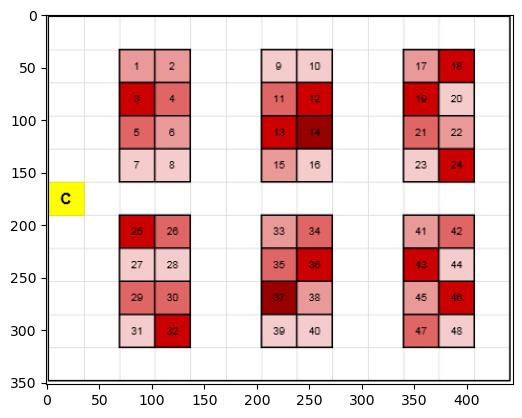

In [ ]:
image = io.imread("https://drive.google.com/uc?export=view&id=1PHW426bY8Q31gBqEsvE5FFzhGnTuvjox")
plt.imshow(image)
plt.show()

In [ ]:
import numpy as np
import random
import csv
import matplotlib.pyplot as plt
import heapq
# 1. CONFIGURACIÓN Y PRE-CÁLCULOS
NUM_PRODUCTOS = 48
TAMANO_POBLACION = 100
GENERACIONES = 200
TASA_ELITISMO = 0.2  
TASA_MUTACION = 0.8  

cols_estantes = 6
filas_estantes = 8
posiciones_estantes = [(x, y) for y in range(filas_estantes) for x in range(cols_estantes)]

# --- INICIO DEL CÁLCULO CON A* ---
def coord_fisica(x, y):
    """
    Mapea coordenadas lógicas a físicas.
    Incluye pasillos verticales internos, pasillo central horizontal,
    y deja espacio para pasillos en los bordes (superior, inferior y derecho).
    """

    vx = x if x < 2 else (x + 1 if x < 4 else x + 2)

    vy = (y + 1) if y < 4 else (y + 2)
    return vx, vy

obstaculos = set(coord_fisica(x, y) for x, y in posiciones_estantes)
inicio_fisico = (-1, 5)
def a_star(inicio, destino):
    movimientos = [(0, 1), (0, -1), (1, 0), (-1, 0)] 
    open_set = []
    heapq.heappush(open_set, (0, 0, inicio))
    g_costs = {inicio: 0}
    
    limite_x_min, limite_x_max = -1, 8
    limite_y_min, limite_y_max = 0, 10
    
    while open_set:
        _, costo_g, actual = heapq.heappop(open_set)
        
        if actual == destino:
            return costo_g 
            
        for dx, dy in movimientos:
            vecino = (actual[0] + dx, actual[1] + dy)
            
            if not (limite_x_min <= vecino[0] <= limite_x_max and limite_y_min <= vecino[1] <= limite_y_max):
                continue
                
            if vecino in obstaculos and vecino != destino:
                continue
                
            nuevo_costo_g = costo_g + 1
            
            if vecino not in g_costs or nuevo_costo_g < g_costs[vecino]:
                g_costs[vecino] = nuevo_costo_g
                heuristica = abs(vecino[0] - destino[0]) + abs(vecino[1] - destino[1])
                costo_f = nuevo_costo_g + heuristica
                heapq.heappush(open_set, (costo_f, nuevo_costo_g, vecino))
                
    return float('inf') 

distancias_precalculadas = {}
print("Pre-calculando distancias con A* (perímetro completo habilitado)...")
for i, pos in enumerate(posiciones_estantes):
    destino_fisico = coord_fisica(pos[0], pos[1])
    distancias_precalculadas[i] = a_star(inicio_fisico, destino_fisico)
# --- FIN DEL CÁLCULO CON A* ---

# 2. CARGA DE ÓRDENES
def cargar_ordenes(ruta_archivo):
    ordenes = []
    try:
        with open(ruta_archivo, 'r') as file:
            reader = csv.reader(file)
            for row in reader:
                orden = [int(p) - 1 for p in row if p.strip()]
                ordenes.append(orden)
    except FileNotFoundError:
        print("Archivo de órdenes no encontrado. Generando aleatorias.")
        ordenes = [[random.randint(0, 47) for _ in range(5)] for _ in range(20)]
    return ordenes

ordenes = cargar_ordenes('ordenes.csv')

# 3. FUNCIONES DEL ALGORITMO GENÉTICO
def crear_individuo():
    individuo = list(range(NUM_PRODUCTOS)) 
    random.shuffle(individuo)  
    return individuo

def calcular_costo_ruta(individuo, ordenes):
    costo_total = 0
    for orden in ordenes:
        for producto in orden:
            indice_estante = individuo.index(producto)
            costo_total += distancias_precalculadas[indice_estante] * 2
    return costo_total

def evaluar_poblacion(poblacion, ordenes):
    evaluaciones = []
    for ind in poblacion:
        costo = calcular_costo_ruta(ind, ordenes)
        fitness = 1.0 / (costo + 1e-6)
        evaluaciones.append((ind, fitness, costo))
    evaluaciones.sort(key=lambda x: x[1], reverse=True)
    return evaluaciones

def seleccion_ruleta(evaluaciones):
    suma_fitness = sum([eval[1] for eval in evaluaciones])
    limite = random.uniform(0, suma_fitness)
    acumulado = 0
    for eval in evaluaciones:
        acumulado += eval[1]
        if acumulado >= limite:
            return eval[0]
    return evaluaciones[-1][0]

def mutacion_intercambio(individuo):
    if random.random() < TASA_MUTACION:
        idx1, idx2 = random.sample(range(NUM_PRODUCTOS), 2)
        individuo[idx1], individuo[idx2] = individuo[idx2], individuo[idx1]
    return individuo

# 4. BUCLE PRINCIPAL DEL ALGORITMO GENÉTICO
def ejecutar_algoritmo_genetico():
    print("Iniciando Algoritmo Genético...")
    poblacion = [crear_individuo() for _ in range(TAMANO_POBLACION)]
    mejores_costos_historicos = []
    mejor_solucion_global = None
    mejor_costo_global = float('inf')

    evaluaciones_iniciales = evaluar_poblacion(poblacion, ordenes)
    distribucion_inicial = list(evaluaciones_iniciales[0][0])

    for generacion in range(GENERACIONES):
        evaluaciones = evaluar_poblacion(poblacion, ordenes)
        mejor_actual, _, costo_actual = evaluaciones[0]
        mejores_costos_historicos.append(costo_actual)
        
        if costo_actual < mejor_costo_global:
            mejor_costo_global = costo_actual
            mejor_solucion_global = list(mejor_actual)
            
        num_elites = int(TAMANO_POBLACION * TASA_ELITISMO)
        nueva_poblacion = [list(ind) for ind, fit, cost in evaluaciones[:num_elites]]
        
        while len(nueva_poblacion) < TAMANO_POBLACION:
            padre = seleccion_ruleta(evaluaciones)
            hijo = list(padre)
            hijo = mutacion_intercambio(hijo)
            nueva_poblacion.append(hijo)
            
        poblacion = nueva_poblacion
        
        if generacion % 20 == 0:
            print(f"Generación {generacion} | Mejor costo actual: {costo_actual}")
            
    print(f"\nOptimización finalizada. Mejor costo global encontrado: {mejor_costo_global}")
    return mejor_solucion_global, mejores_costos_historicos, distribucion_inicial



# 5. VISUALIZACIÓN DE RESULTADOS

def visualizar_resultado_final(dist_inicial, dist_final, distancias_reales):
    print("Generando visualización planimétrica...")
    
    filas_vis = 11
    cols_vis = 9
    
    matriz_ini = np.full((filas_vis, cols_vis), np.nan)
    matriz_fin = np.full((filas_vis, cols_vis), np.nan)
    matriz_dist = np.full((filas_vis, cols_vis), np.nan)
    
    for i, pos in enumerate(posiciones_estantes):
        vx, vy = coord_fisica(pos[0], pos[1]) 
        matriz_ini[vy, vx] = dist_inicial[i] + 1
        matriz_fin[vy, vx] = dist_final[i] + 1
        matriz_dist[vy, vx] = distancias_reales[i]

    fig, axes = plt.subplots(1, 2, figsize=(18, 10))
    cmap = plt.cm.RdYlGn_r
    cmap.set_bad(color='#F0F0F0') 

    titulos = ['Generación 0 (Distribución Aleatoria)', 'Generación Optimizada (Algoritmo Genético)']
    matrices_ids = [matriz_ini, matriz_fin]

    for idx, ax in enumerate(axes):
        cax = ax.matshow(matriz_dist, cmap=cmap, alpha=0.6)
        
        for i, pos in enumerate(posiciones_estantes):
            vx, vy = coord_fisica(pos[0], pos[1])
            valor_id = int(matrices_ids[idx][vy, vx])
            ax.text(vx, vy, str(valor_id), va='center', ha='center', 
                    fontweight='bold', fontsize=11, color='black')

        
        ax.scatter(-0.8, 5, s=300, c='#0052cc', marker='s', label='Estación de Carga', edgecolors='black', zorder=5)
        
        ax.set_title(titulos[idx], pad=20, fontsize=14, fontweight='bold')
        ax.set_xticks([]) 
        ax.set_yticks([])
        ax.legend(loc='upper left', bbox_to_anchor=(0, 1.05))

    cbar = fig.colorbar(cax, ax=axes, orientation='horizontal', fraction=0.04, pad=0.05)
    cbar.set_label('Costo de Distancia Real (Métrica A*)', fontsize=12, fontweight='bold')
    
    plt.suptitle('Planimetría del Almacén con Perímetro Navegable', fontsize=18, fontweight='bold', y=0.98)
    plt.show()


# EJECUCIÓN DEL FLUJO COMPLETO

mejor_distribucion, historial, distribucion_inicial = ejecutar_algoritmo_genetico()
visualizar_resultado_final(distribucion_inicial, mejor_distribucion, distancias_precalculadas)

Pre-calculando distancias con A* (perímetro completo habilitado)...
Iniciando Algoritmo Genético...
Generación 0 | Mejor costo actual: 4600
Generación 20 | Mejor costo actual: 4250
Generación 40 | Mejor costo actual: 4072
Generación 60 | Mejor costo actual: 4010
Generación 80 | Mejor costo actual: 3946
Generación 100 | Mejor costo actual: 3910
Generación 120 | Mejor costo actual: 3880
Generación 140 | Mejor costo actual: 3862
Generación 160 | Mejor costo actual: 3844
Generación 180 | Mejor costo actual: 3840

Optimización finalizada. Mejor costo global encontrado: 3836
Generando visualización planimétrica...
